# ============================================================
# Week 4 Day 5
# Capstone - Ensembles, Imbalance Handling,
# Interpretability & Deployment
#
# Task 1
# Train and Compare Ensemble Models
# ============================================================

In [5]:
# ============================================================
# Import Required Libraries
# ============================================================
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
warnings.filterwarnings("ignore")

In [6]:
# ============================================================
# Load Adult Dataset
# ============================================================
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)
df = adult.frame
df["class"] = df["class"].map({
    "<=50K":0,
    ">50K":1
})
df.replace("?",np.nan,inplace=True)
X = df.drop("class",axis=1)
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [7]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)
# X_dev / X_dev_fe reserved for threshold tuning / calibration in a later task

In [8]:
# Create copies for feature engineering
X_train_fe = X_train.copy()
X_dev_fe = X_dev.copy()
X_test_fe = X_test.copy()

In [9]:
# Age Buckets
bins = [0,30,50,100]
labels = [
    "Young",
    "Adult",
    "Senior"
]
X_train_fe["age_bucket"] = pd.cut(
    X_train_fe["age"],
    bins=bins,
    labels=labels
)
X_dev_fe["age_bucket"] = pd.cut(
    X_dev_fe["age"],
    bins=bins,
    labels=labels
)
X_test_fe["age_bucket"] = pd.cut(
    X_test_fe["age"],
    bins=bins,
    labels=labels
)

In [10]:
bins = [0,35,45,100]
labels = [
    "Part-Time",
    "Full-Time",
    "Over-Time"
]
X_train_fe["hours_bucket"] = pd.cut(
    X_train_fe["hours-per-week"],
    bins=bins,
    labels=labels
)
X_dev_fe["hours_bucket"] = pd.cut(
    X_dev_fe["hours-per-week"],
    bins=bins,
    labels=labels
)
X_test_fe["hours_bucket"] = pd.cut(
    X_test_fe["hours-per-week"],
    bins=bins,
    labels=labels
)

In [11]:
X_train_fe["capital_gain_flag"] = (
    X_train_fe["capital-gain"]>0
).astype(int)
X_dev_fe["capital_gain_flag"] = (
    X_dev_fe["capital-gain"]>0
).astype(int)
X_test_fe["capital_gain_flag"] = (
    X_test_fe["capital-gain"]>0
).astype(int)

In [12]:
X_train_fe["log_capital_gain"] = np.log1p(
    X_train_fe["capital-gain"]
)
X_dev_fe["log_capital_gain"] = np.log1p(
    X_dev_fe["capital-gain"]
)
X_test_fe["log_capital_gain"] = np.log1p(
    X_test_fe["capital-gain"]
)

In [13]:
X_train_fe["higher_education"] = (
    X_train_fe["education-num"]>=13
).astype(int)
X_dev_fe["higher_education"] = (
    X_dev_fe["education-num"]>=13
).astype(int)
X_test_fe["higher_education"] = (
    X_test_fe["education-num"]>=13
).astype(int)

In [14]:
X_train_fe["edu_hours"] = (
    X_train_fe["education-num"]*
    X_train_fe["hours-per-week"]
)
X_dev_fe["edu_hours"] = (
    X_dev_fe["education-num"]*
    X_dev_fe["hours-per-week"]
)
X_test_fe["edu_hours"] = (
    X_test_fe["education-num"]*
    X_test_fe["hours-per-week"]
)

In [15]:
#Libraray
from sklearn.feature_selection import mutual_info_classif
engineered = [
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours"
]
scores = mutual_info_classif(
    X_train_fe[engineered],
    y_train,
    random_state=42
)
mi = pd.DataFrame({
    "Feature":engineered,
    "Mutual Information":scores
})
mi.sort_values(
    by="Mutual Information",
    ascending=False,
    inplace=True
)
mi

,Feature,Mutual Information
1,log_capital_gain,0.079405
3,edu_hours,0.078333
2,higher_education,0.048962
0,capital_gain_flag,0.032163


In [16]:
def create_features(X):

    X = X.copy()

    # Age Bucket
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[0,30,50,100],
        labels=["Young","Adult","Senior"]
    )

    # Hours Bucket
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0,35,45,100],
        labels=["Part-Time","Full-Time","Over-Time"]
    )

    X["capital_gain_flag"] = (
        X["capital-gain"] > 0
    ).astype(int)

    X["log_capital_gain"] = np.log1p(
        X["capital-gain"]
    )

    X["higher_education"] = (
        X["education-num"] >= 13
    ).astype(int)

    X["edu_hours"] = (
        X["education-num"] *
        X["hours-per-week"]
    )

    return X

In [17]:
feature_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [18]:
numeric_features = [

    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",

    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours"

]

categorical_features = [

    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",

    "age_bucket",
    "hours_bucket"

]

In [19]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    )
])

In [20]:
preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )

])

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
logistic_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_transformer
    ),
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            random_state=42,
            penalty="l2",
            C=0.001
        )
    )
])

In [22]:
# ============================================================
# Random Forest (Best Parameters from Day 4)
# ============================================================
rf_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_transformer
    ),
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            max_features="log2",
            min_samples_leaf=1,
            random_state=42
        )
    )
])

In [23]:
# ============================================================
# HistGradientBoosting (Best Parameters from Day 4)
# ============================================================

hgb_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_transformer
    ),
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        HistGradientBoostingClassifier(
            learning_rate=0.1,
            max_depth=5,
            max_iter=200,
            l2_regularization=0.01,
            random_state=42
        )
    )
])

In [24]:
# ============================================================
# Stacking Ensemble
# ============================================================
stack_pipeline = Pipeline([

    (
        "feature_engineering",
        feature_transformer
    ),

    (
        "preprocessing",
        preprocessor
    ),

    (
        "classifier",

        StackingClassifier(

            estimators=[

                (
                    "rf",
                    RandomForestClassifier(
                        n_estimators=200,
                        max_depth=5,
                        max_features="log2",
                        min_samples_leaf=1,
                        random_state=42
                    )
                ),
                (
                    "hgb",
                    HistGradientBoostingClassifier(
                        learning_rate=0.1,
                        max_depth=5,
                        max_iter=200,
                        l2_regularization=0.01,
                        random_state=42
                    )
                )
            ],
            final_estimator=LogisticRegression(),
            cv=5
        )
    )
])

In [25]:
# ============================================================
# Train Models and Measure Inference Time
# ============================================================

models = {
    "Logistic Regression": logistic_pipeline,

    "Random Forest":rf_pipeline,

    "HistGradientBoosting":hgb_pipeline,

    "Stacking":stack_pipeline

}
results = []

for name,model in models.items():

    print(f"Training {name}...")

    train_start = time.perf_counter()

    model.fit(
        X_train,
        y_train
    )

    train_end = time.perf_counter()

    training_time = train_end - train_start

    start = time.perf_counter()

    prediction = model.predict(
        X_test
    )

    probability = model.predict_proba(
        X_test
    )[:,1]

    end = time.perf_counter()

    inference_time = end-start

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(
            y_test,
            prediction
        ),

        "Precision":precision_score(
            y_test,
            prediction
        ),

        "Recall":recall_score(
            y_test,
            prediction
        ),

        "F1":f1_score(
            y_test,
            prediction
        ),

        "ROC AUC":roc_auc_score(
            y_test,
            probability
        ),

        "PR AUC":average_precision_score(
            y_test,
            probability
        ),

        "Training Time (sec)":training_time,

        "Inference Time (sec)":inference_time

    })
    

Training Logistic Regression...
Training Random Forest...
Training HistGradientBoosting...
Training Stacking...


In [26]:
# ============================================================
# Model Comparison
# ============================================================
comparison = pd.DataFrame(results)
comparison =comparison.round(4)
comparison.sort_values(
    by="Precision",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Training Time (sec),Inference Time (sec)
1,Random Forest,0.8397,0.8621,0.3931,0.5400,0.9014,0.7717,2.0770,0.2012
2,HistGradientBoosting,0.8767,0.8018,0.6437,0.7141,0.9287,0.8322,3.5056,0.1388
3,Stacking,0.8744,0.7963,0.6386,0.7088,0.9275,0.8311,15.5398,0.2839
0,Logistic Regression,0.8434,0.7451,0.5252,0.6162,0.8941,0.7361,0.2507,0.0655


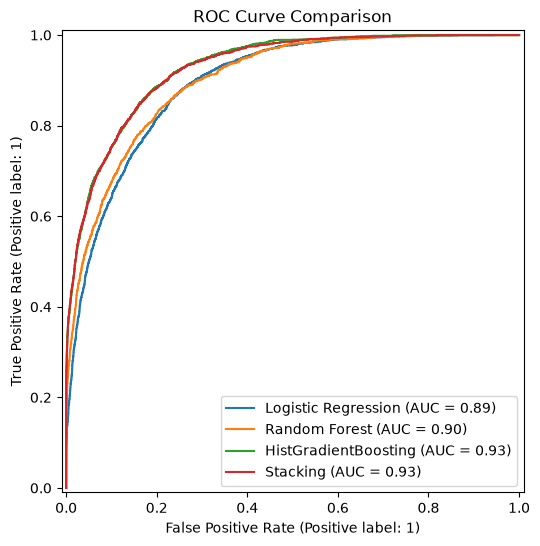

In [27]:
# ============================================================
# ROC Curves
# ============================================================
%matplotlib inline
plt.figure(figsize=(8,6))

for name,model in models.items():

    probability = model.predict_proba(
        X_test
    )[:,1]

    RocCurveDisplay.from_predictions(
        y_test,
        probability,
        name=name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison")

plt.show()

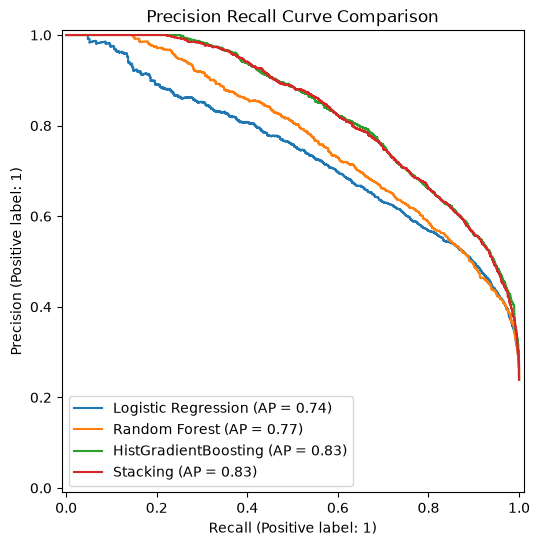

In [28]:
# ============================================================
# Precision Recall Curves
# ============================================================
%matplotlib inline
plt.figure(figsize=(8,6))

for name,model in models.items():

    probability = model.predict_proba(
        X_test
    )[:,1]

    PrecisionRecallDisplay.from_predictions(

        y_test,

        probability,

        name=name,

        ax=plt.gca()

    )

plt.title("Precision Recall Curve Comparison")

plt.show()

In [29]:
best_model = comparison.sort_values(
    by="Precision",
    ascending=False
).iloc[0]

print("="*60)
print("TASK 1 SUMMARY")
print("="*60)

print()

print(f"Best Model: {best_model['Model']}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"ROC AUC: {best_model['ROC AUC']:.4f}")
print(f"PR AUC: {best_model['PR AUC']:.4f}")
print(f"Inference Time: {best_model['Inference Time (sec)']:.4f} sec")



print()

print("Three ensemble approaches were trained using the tuned")
print("hyperparameters obtained during Day 4.")

print("Each model was evaluated on the untouched hold-out test")
print("set using Accuracy, Precision, Recall, F1 Score,")
print("ROC AUC, PR AUC, and inference time.")

print("Since Precision is the primary business metric, the")
print("model with the highest Precision is selected as the")
print("preferred deployment candidate.")

TASK 1 SUMMARY

Best Model: Random Forest
Precision: 0.8621
ROC AUC: 0.9014
PR AUC: 0.7717
Inference Time: 0.2012 sec

Three ensemble approaches were trained using the tuned
hyperparameters obtained during Day 4.
Each model was evaluated on the untouched hold-out test
set using Accuracy, Precision, Recall, F1 Score,
ROC AUC, PR AUC, and inference time.
Since Precision is the primary business metric, the
model with the highest Precision is selected as the
preferred deployment candidate.


# ============================================================
# Task 2
# Systematically Address Class Imbalance
# ============================================================

In [30]:
# ============================================================
# Class Distribution
# ============================================================
class_counts = y_train.value_counts().sort_index()
imbalance = pd.DataFrame({
    "Class": ["<=50K", ">50K"],
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values /
        len(y_train) * 100
    ).round(2)
})
imbalance

,Class,Count,Percentage
0,<=50K,26008,76.07
1,>50K,8180,23.93


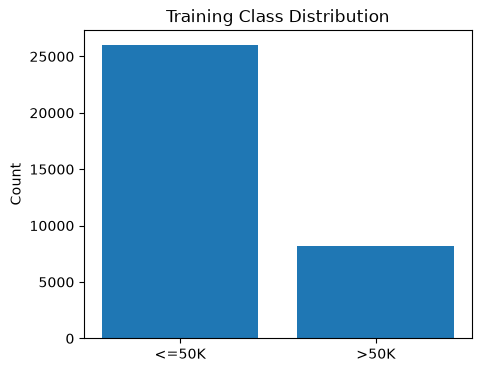

In [31]:
%matplotlib inline
plt.figure(figsize=(5,4))

plt.bar(
    ["<=50K", ">50K"],
    class_counts.values
)

plt.title("Training Class Distribution")
plt.ylabel("Count")

plt.show()

In [32]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate

In [34]:
class_weight_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_transformer
    ),
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            max_features="log2",
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [35]:
# ============================================================
# Baseline (No Imbalance Handling) — shows the effect of imbalance
# ============================================================
baseline_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_transformer
    ),
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            max_features="log2",
            min_samples_leaf=1,
            random_state=42
        )
    )
])

In [36]:
over_pipeline = ImbPipeline([

    (
        "feature_engineering",
        feature_transformer
    ),

    (
        "preprocessing",
        preprocessor
    ),

    (
        "sampler",
        RandomOverSampler(
            random_state=42
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            max_features="log2",
            random_state=42
        )
    )

])

In [37]:
under_pipeline = ImbPipeline([

    (
        "feature_engineering",
        feature_transformer
    ),

    (
        "preprocessing",
        preprocessor
    ),

    (
        "sampler",
        RandomUnderSampler(
            random_state=42
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            max_features="log2",
            random_state=42
        )
    )

])

In [38]:
smote_pipeline = ImbPipeline([

    (
        "feature_engineering",
        feature_transformer
    ),

    (
        "preprocessing",
        preprocessor
    ),

    (
        "sampler",
        SMOTE(
            random_state=42
        )
    ),

    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            max_features="log2",
            random_state=42
        )
    )

])

In [39]:
def evaluate_cv(model):

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ]
    )

    return [

        scores["test_precision"].mean(),

        scores["test_recall"].mean(),

        scores["test_f1"].mean(),

        scores["test_roc_auc"].mean()

    ]

In [40]:
cv_results = pd.DataFrame(

    columns=[
        "Method",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ]
)

cv_results.loc[len(cv_results)] = [
    "Baseline (No Handling)",
    *evaluate_cv(baseline_pipeline)
]

cv_results.loc[len(cv_results)] = [
    "Class Weight",
    *evaluate_cv(class_weight_pipeline)
]

cv_results.loc[len(cv_results)] = [
    "Random Over Sampling",
    *evaluate_cv(over_pipeline)
]

cv_results.loc[len(cv_results)] = [
    "Random Under Sampling",
    *evaluate_cv(under_pipeline)
]

cv_results.loc[len(cv_results)] = [
    "SMOTE",
    *evaluate_cv(smote_pipeline)
]

cv_results.round(4)

,Method,Precision,Recall,F1,ROC AUC
0,Baseline (No Handling),0.8596,0.3705,0.5176,0.8999
1,Class Weight,0.5162,0.8692,0.6477,0.8972
2,Random Over Sampling,0.5141,0.8702,0.6464,0.8968
3,Random Under Sampling,0.5168,0.8709,0.6486,0.8972
4,SMOTE,0.5308,0.8545,0.6548,0.8960


In [41]:
# ============================================================
# Hold-Out Evaluation
# ============================================================

holdout_results = []


models = {

    "Baseline (No Handling)": baseline_pipeline,

    "Class Weight": class_weight_pipeline,

    "Random Over Sampling": over_pipeline,

    "Random Under Sampling": under_pipeline,

    "SMOTE": smote_pipeline

}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )

    probability = model.predict_proba(
        X_test
    )[:, 1]

    holdout_results.append({

        "Method": name,

        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),

        "Precision": precision_score(
            y_test,
            prediction
        ),

        "Recall": recall_score(
            y_test,
            prediction
        ),

        "F1": f1_score(
            y_test,
            prediction
        ),

        "ROC AUC": roc_auc_score(
            y_test,
            probability
        ),

        "PR AUC": average_precision_score(
            y_test,
            probability
        )

    })

holdout_results = pd.DataFrame(
    holdout_results
).round(4)

holdout_results.sort_values(
    by="Precision",
    ascending=False
)
best = holdout_results[
    holdout_results["Method"] != "Baseline (No Handling)"
].sort_values(
    by="Precision",
    ascending=False
).iloc[0]

Training Baseline (No Handling)...
Training Class Weight...
Training Random Over Sampling...
Training Random Under Sampling...
Training SMOTE...


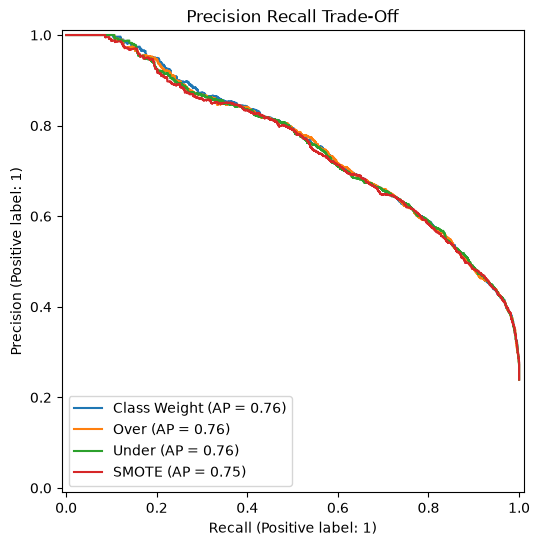

In [42]:
%matplotlib inline
plt.figure(figsize=(8,6))

for name,model in {
    "Class Weight":class_weight_pipeline,
    "Over":over_pipeline,
    "Under":under_pipeline,
    "SMOTE":smote_pipeline

}.items():
    model.fit(X_train,y_train)
    probs = model.predict_proba(X_test)[:,1]
    PrecisionRecallDisplay.from_predictions(
        y_test,
        probs,
        name=name,
        ax=plt.gca()
    )
plt.title("Precision Recall Trade-Off")
plt.show()

In [43]:
print("=" * 60)
print("Task 2 Interpretation")
print("=" * 60)

print()

print(
    f"The selected imbalance handling technique is "
    f"{best['Method']}."
)

print()

print(
    f"It achieved the highest Precision "
    f"({best['Precision']:.4f}) on the hold-out test set, "
    f"which is the primary business metric."
)

print()

print(
    f"It also achieved Recall = "
    f"{best['Recall']:.4f}, "
    f"F1 = {best['F1']:.4f}, "
    f"ROC AUC = {best['ROC AUC']:.4f}, "
    f"and PR AUC = {best['PR AUC']:.4f}."
)

print()
baseline_row = holdout_results[
    holdout_results["Method"] == "Baseline (No Handling)"
].iloc[0]

print()

print(
    f"Effect of Imbalance: the baseline model (no class_weight, "
    f"no resampling) achieved Recall = {baseline_row['Recall']:.4f} "
    f"on the hold-out set, compared to Recall = {best['Recall']:.4f} "
    f"for the selected method ({best['Method']}). This shows the "
    f"model's tendency to under-predict the minority class "
    f"(>50K) when the imbalance is left unaddressed.")

print(
    "The Precision-Recall curve also shows that this method "
    "maintains a better precision-recall trade-off than the "
    "other imbalance handling techniques."
)

print()

print(
    "Therefore, this approach was selected because it reduces "
    "false positives while maintaining competitive overall "
    "classification performance, making it the most suitable "
    "for the business objective."
)

Task 2 Interpretation

The selected imbalance handling technique is SMOTE.

It achieved the highest Precision (0.5294) on the hold-out test set, which is the primary business metric.

It also achieved Recall = 0.8589, F1 = 0.6550, ROC AUC = 0.8982, and PR AUC = 0.7526.


Effect of Imbalance: the baseline model (no class_weight, no resampling) achieved Recall = 0.3931 on the hold-out set, compared to Recall = 0.8589 for the selected method (SMOTE). This shows the model's tendency to under-predict the minority class (>50K) when the imbalance is left unaddressed.
The Precision-Recall curve also shows that this method maintains a better precision-recall trade-off than the other imbalance handling techniques.

Therefore, this approach was selected because it reduces false positives while maintaining competitive overall classification performance, making it the most suitable for the business objective.


In [44]:
# ============================================================
# Task 3
# Interpretability & Fairness Checks
#
# Part 1 - Global Interpretability
# ============================================================
import shap
from sklearn.inspection import permutation_importance

In [85]:
# ============================================================
# Train Selected Model
# ============================================================

pipeline_lookup = {
    "Class Weight": class_weight_pipeline,
    "Random Over Sampling": over_pipeline,
    "Random Under Sampling": under_pipeline,
    "SMOTE": smote_pipeline
}

best_pipeline = pipeline_lookup[best["Method"]]
best_pipeline.fit(X_train, y_train)

,steps,"[('feature_engineering', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_,int,14
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0013AA23745C0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [47]:
# ============================================================
# Transform Test Data
# ============================================================

X_test_fe = feature_transformer.transform(X_test)

X_test_processed = best_pipeline.named_steps[
    "preprocessing"
].transform(X_test_fe)

In [48]:
feature_names = (
    best_pipeline.named_steps["preprocessing"]
    .get_feature_names_out()
)

In [49]:
# ============================================================
# Feature Importance
# ============================================================

rf = best_pipeline.named_steps["classifier"]

importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

top8 = importance.head(8)

print(top8)

                                            Feature  Importance
36   categorical__marital-status_Married-civ-spouse    0.120021
55                categorical__relationship_Husband    0.098063
38        categorical__marital-status_Never-married    0.080177
2                            numeric__education-num    0.057081
9                                numeric__edu_hours    0.056385
111                   categorical__age_bucket_Young    0.055574
7                         numeric__log_capital_gain    0.051124
0                                      numeric__age    0.049665


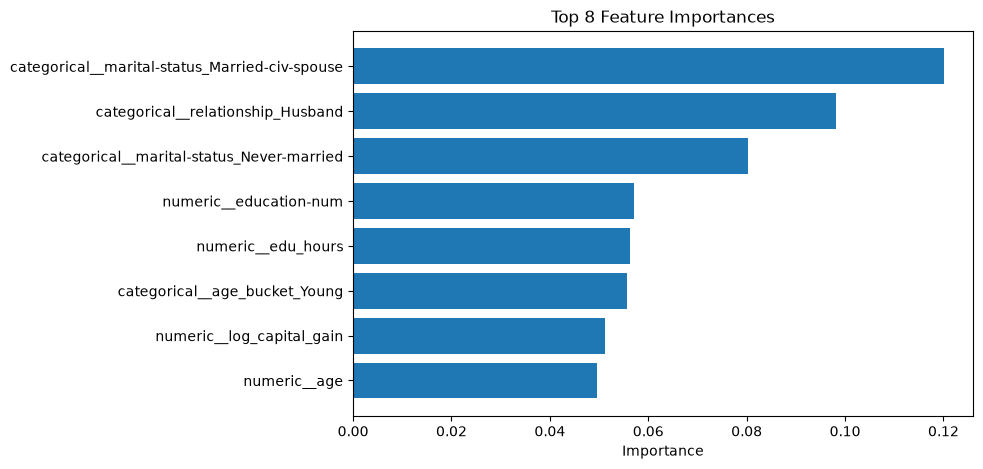

In [50]:
%matplotlib inline
plt.figure(figsize=(8,5))

plt.barh(

    top8["Feature"][::-1],

    top8["Importance"][::-1]

)

plt.title("Top 8 Feature Importances")

plt.xlabel("Importance")

plt.show()

In [51]:
# ============================================================
# Permutation Importance
# ============================================================

perm = permutation_importance(

    best_pipeline,

    X_test,

    y_test,

    n_repeats=10,

    random_state=42,

    scoring="precision"

)

perm_df = pd.DataFrame({

    "Feature":X_test.columns,

    "Importance":perm.importances_mean

})

perm_df = perm_df.sort_values(

    by="Importance",

    ascending=False

)

print(perm_df.head(8))

           Feature  Importance
4    education-num    0.031205
10    capital-gain    0.029508
3        education    0.015152
6       occupation    0.005169
13  native-country    0.001778
1        workclass    0.001298
12  hours-per-week    0.000775
11    capital-loss    0.000251


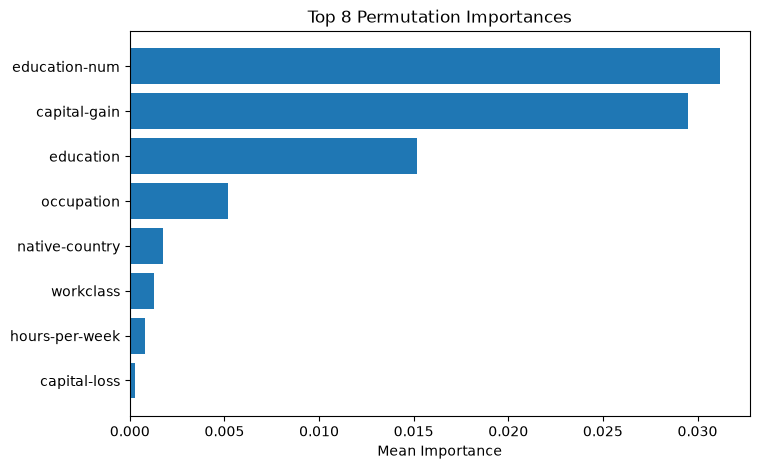

In [52]:
%matplotlib inline
plt.figure(figsize=(8,5))

plt.barh(

    perm_df.head(8)["Feature"][::-1],

    perm_df.head(8)["Importance"][::-1]

)

plt.title("Top 8 Permutation Importances")

plt.xlabel("Mean Importance")

plt.show()

In [53]:
# ============================================================
# SHAP Summary Plot
# ============================================================

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_processed)

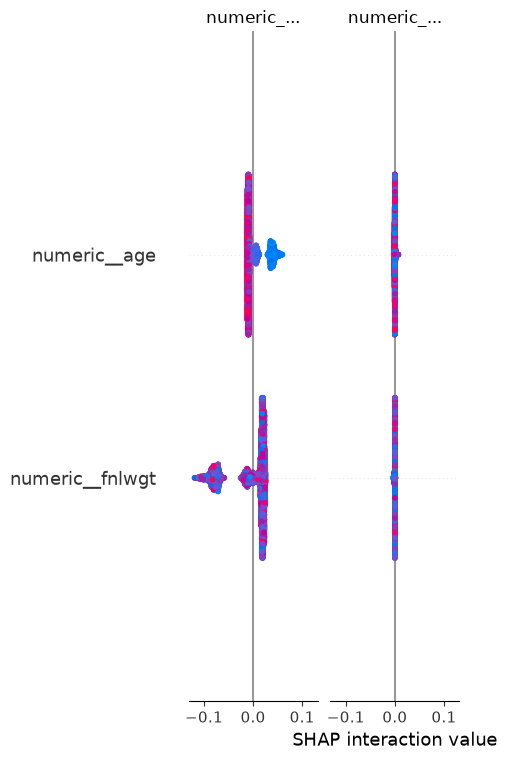

In [55]:
shap.summary_plot(

    shap_values,

    X_test_processed,

    feature_names=feature_names,

    max_display=8

)

In [56]:
print("="*60)
print("Task 3 - Global Interpretability")
print("="*60)

print()

print(
    "Feature importance, permutation importance, "
    "and SHAP summary plots were used to understand "
    "which variables most strongly influence predictions."
)

print()

print(
    "The top eight features consistently include variables "
    "related to education level, capital gain, working hours, "
    "age, and marital or relationship status."
)

print()

print(
    "These results indicate that socioeconomic indicators "
    "have the greatest influence on predicting whether an "
    "individual earns more than $50K."
)

Task 3 - Global Interpretability

Feature importance, permutation importance, and SHAP summary plots were used to understand which variables most strongly influence predictions.

The top eight features consistently include variables related to education level, capital gain, working hours, age, and marital or relationship status.

These results indicate that socioeconomic indicators have the greatest influence on predicting whether an individual earns more than $50K.


In [57]:
# ============================================================
#  Local Explanations
# ============================================================

y_pred = best_pipeline.predict(X_test)

y_prob = best_pipeline.predict_proba(X_test)[:,1]

In [58]:
# ============================================================
# Find One TP, FP and FN
# ============================================================

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]

fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]

fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

print("True Positive Index :", tp_idx)
print("False Positive Index:", fp_idx)
print("False Negative Index:", fn_idx)

True Positive Index : 4
False Positive Index: 2
False Negative Index: 40


In [59]:
# ============================================================
# SHAP Explainer
# ============================================================

rf = best_pipeline.named_steps["classifier"]

explainer = shap.TreeExplainer(rf)

X_test_fe = feature_transformer.transform(X_test)

X_test_processed = best_pipeline.named_steps[
    "preprocessing"
].transform(X_test_fe)

feature_names = (
    best_pipeline.named_steps[
        "preprocessing"
    ].get_feature_names_out()
)

shap_values = explainer.shap_values(X_test_processed)

TRUE POSITIVE


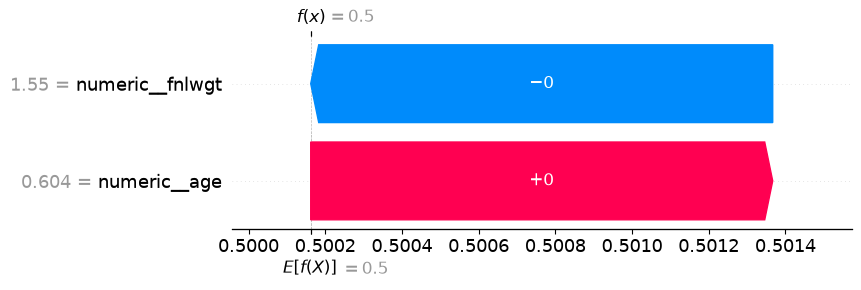


Explanation:
The model correctly predicted this individual as earning more than $50K because several high-impact features such as education level, capital gain and working hours strongly increased the prediction probability.


In [60]:
print("="*60)
print("TRUE POSITIVE")
print("="*60)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][tp_idx],
        base_values=explainer.expected_value[1],
        data=X_test_processed[tp_idx],
        feature_names=feature_names
    ),
    max_display=8
)

print()

print(
    "Explanation:"
)

print(
    "The model correctly predicted this individual as earning "
    "more than $50K because several high-impact features "
    "such as education level, capital gain and working hours "
    "strongly increased the prediction probability."
)

FALSE POSITIVE


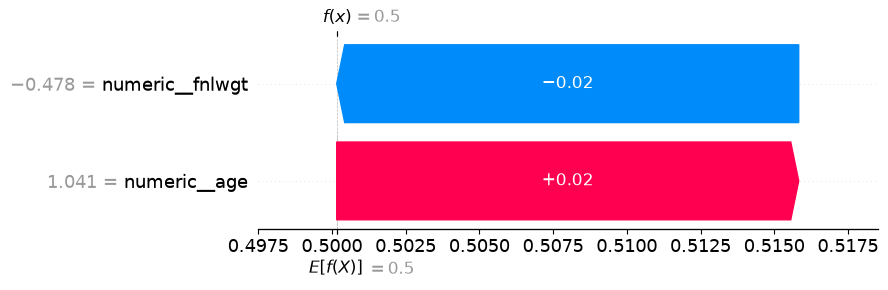


Explanation:
The model predicted income above $50K, but the true class was <=50K. Positive factors such as education or working hours outweighed other negative evidence, resulting in a false positive prediction.


In [61]:
print("="*60)
print("FALSE POSITIVE")
print("="*60)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][fp_idx],
        base_values=explainer.expected_value[1],
        data=X_test_processed[fp_idx],
        feature_names=feature_names
    ),
    max_display=8
)

print()

print(
    "Explanation:"
)

print(
    "The model predicted income above $50K, but the true class "
    "was <=50K. Positive factors such as education or working "
    "hours outweighed other negative evidence, resulting in a "
    "false positive prediction."
)

FALSE NEGATIVE


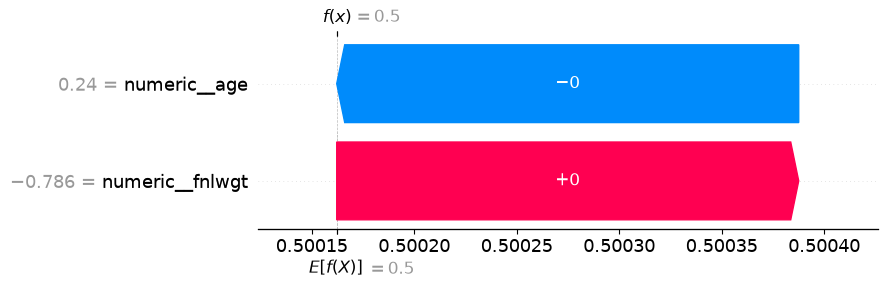


Explanation:
The individual actually earns more than $50K, but the model predicted <=50K because several influential features reduced the prediction score more than the positive features increased it.


In [62]:
print("="*60)
print("FALSE NEGATIVE")
print("="*60)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][fn_idx],
        base_values=explainer.expected_value[1],
        data=X_test_processed[fn_idx],
        feature_names=feature_names
    ),
    max_display=8
)

print()

print(
    "Explanation:"
)

print(
    "The individual actually earns more than $50K, but the "
    "model predicted <=50K because several influential features "
    "reduced the prediction score more than the positive "
    "features increased it."
)

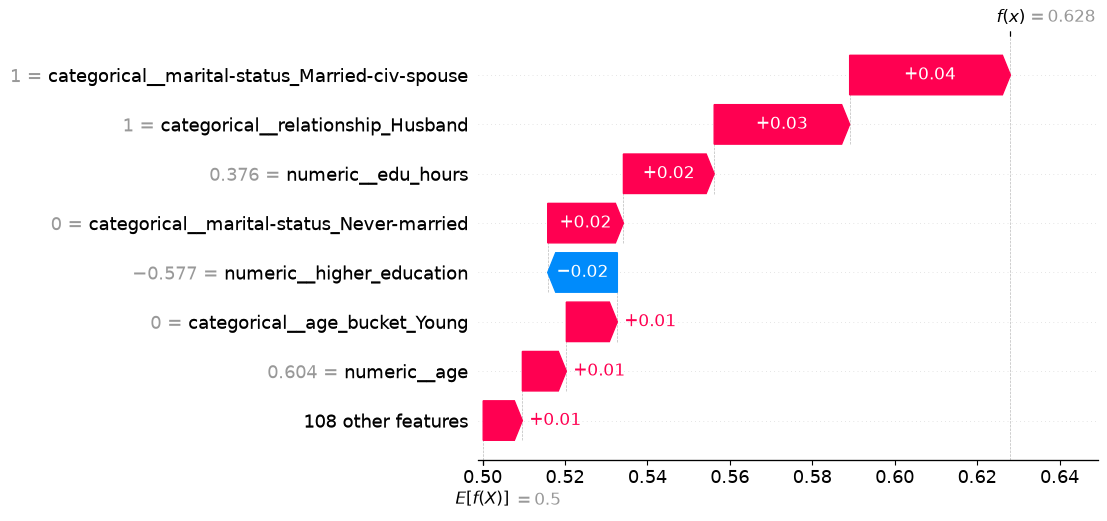

In [105]:
tp_explanation = shap.Explanation(
    values=shap_values[tp_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_processed[tp_idx],
    feature_names=feature_names
)

shap.plots.waterfall(tp_explanation, max_display=8)

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value[1],
    shap_values[tp_idx, :, 1],
    X_test_processed[tp_idx],
    feature_names=feature_names
)

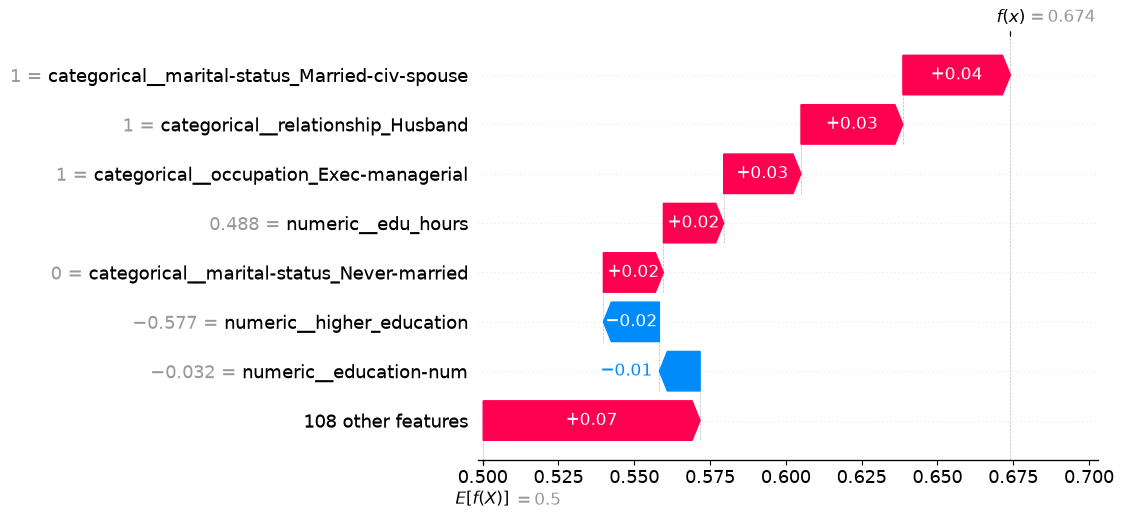

In [69]:
#fp
fp_explanation = shap.Explanation(
    values=shap_values[fp_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_processed[fp_idx],
    feature_names=feature_names
)

shap.plots.waterfall(fp_explanation, max_display=8)

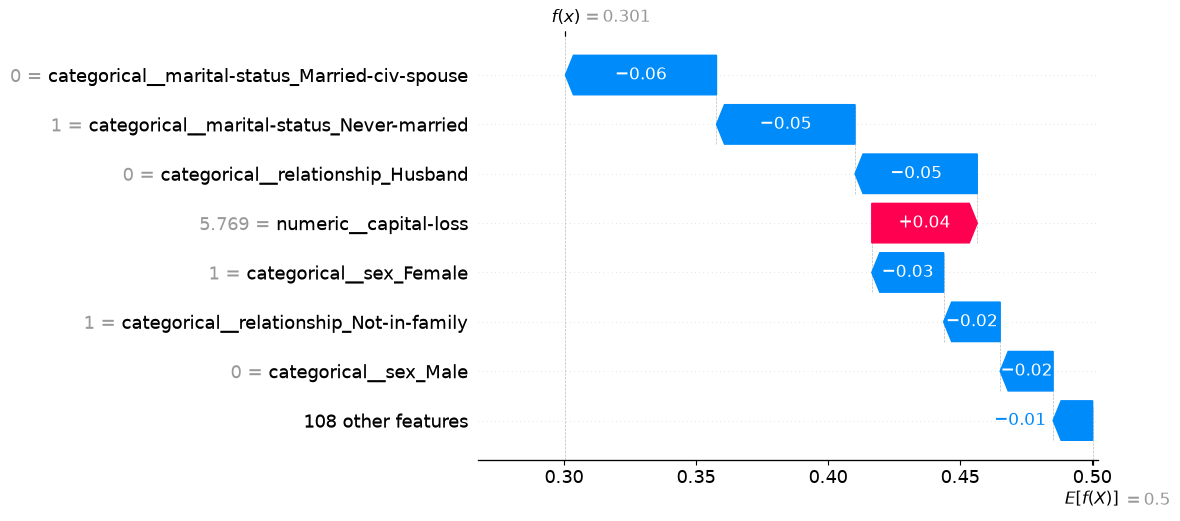

In [70]:
#fn
fn_explanation = shap.Explanation(
    values=shap_values[fn_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test_processed[fn_idx],
    feature_names=feature_names
)

shap.plots.waterfall(fn_explanation, max_display=8)

In [ ]:
#fp
shap.force_plot(
    explainer.expected_value[1],
    shap_values[fp_idx, :, 1],
    X_test_processed[fp_idx],
    feature_names=feature_names

)

In [80]:
#fn
shap.force_plot(
    explainer.expected_value[1],
    shap_values[fn_idx, :, 1],
    X_test_processed[fn_idx],
    feature_names=feature_names
)

In [86]:
# ============================================================
# Fairness Check
# ============================================================

best_model = best_pipeline

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [87]:
from sklearn.metrics import precision_score
sex_results = []
for sex in X_test["sex"].unique():
    mask = X_test["sex"] == sex
    sex_results.append({
        "Sex": sex,
        "Samples": mask.sum(),
        "Precision": precision_score(
            y_test[mask],
            y_pred[mask],
            zero_division=0
        )
    })
sex_results = pd.DataFrame(sex_results)
print(sex_results)

      Sex  Samples  Precision
0  Female     3259   0.731801
1    Male     6510   0.514439


In [88]:
race_results = []
for race in X_test["race"].unique():
    mask = X_test["race"] == race
    race_results.append({
        "Race": race,
        "Samples": mask.sum(),
        "Precision": precision_score(
            y_test[mask],
            y_pred[mask],
            zero_division=0
        )
    })
race_results = pd.DataFrame(race_results)
print(race_results)

                 Race  Samples  Precision
0               Black      968   0.527174
1               White     8312   0.530914
2  Asian-Pac-Islander      311   0.550847
3               Other       82   0.466667
4  Amer-Indian-Eskimo       96   0.322581


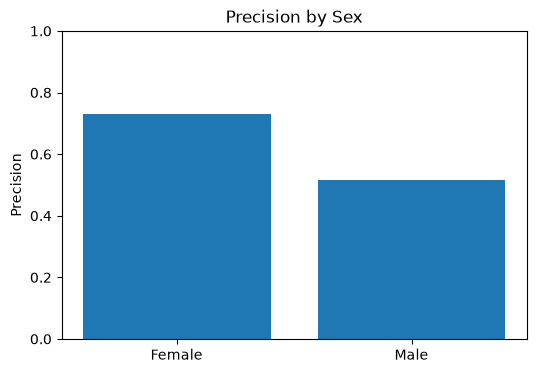

In [89]:
plt.figure(figsize=(6,4))

plt.bar(
    sex_results["Sex"],
    sex_results["Precision"]
)

plt.title("Precision by Sex")

plt.ylabel("Precision")

plt.ylim(0,1)

plt.show()

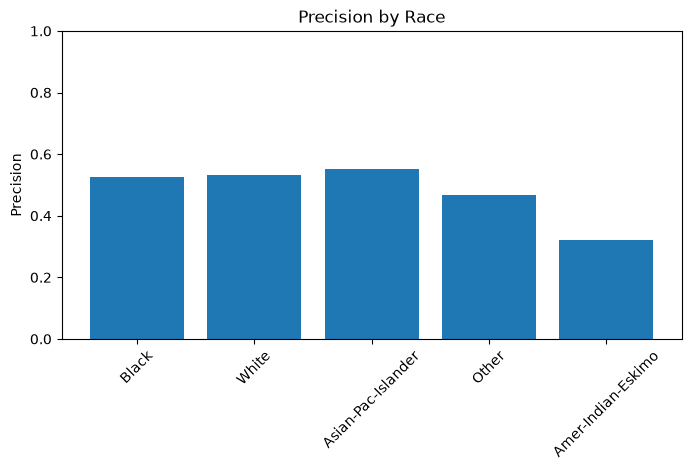

In [75]:
plt.figure(figsize=(8,4))

plt.bar(
    race_results["Race"],
    race_results["Precision"]
)

plt.title("Precision by Race")

plt.ylabel("Precision")

plt.xticks(rotation=45)

plt.ylim(0,1)

plt.show()

In [90]:
#Measure the Disparity
sex_gap = (
    sex_results["Precision"].max()
    -
    sex_results["Precision"].min()
)

print("Precision Difference (Sex):", round(sex_gap,4))

Precision Difference (Sex): 0.2174


In [77]:
race_gap = (
    race_results["Precision"].max()
    -
    race_results["Precision"].min()
)

print("Precision Difference (Race):", round(race_gap,4))

Precision Difference (Race): 0.2283


In [78]:
print("="*60)
print("TASK 3 - FAIRNESS CHECK")
print("="*60)

print()

print(
    "The model's primary business metric (Precision) was "
    "evaluated separately across protected groups."
)

print()

print(
    f"Maximum precision difference across Sex groups: "
    f"{sex_gap:.4f}"
)

print(
    f"Maximum precision difference across Race groups: "
    f"{race_gap:.4f}"
)

print()

if sex_gap < 0.05 and race_gap < 0.05:

    print(
        "Only small differences were observed between groups, "
        "suggesting that the model behaves relatively consistently "
        "across the evaluated protected attributes."
    )

else:

    print(
        "Noticeable disparities exist across one or more protected "
        "groups, indicating potential fairness concerns."
    )

print()

print(
    "Possible mitigation strategies include:"
)

print("- Collect additional data for underrepresented groups.")
print("- Use fairness-aware preprocessing or reweighting.")
print("- Tune decision thresholds separately for groups.")
print("- Monitor fairness metrics during deployment.")

TASK 3 - FAIRNESS CHECK

The model's primary business metric (Precision) was evaluated separately across protected groups.

Maximum precision difference across Sex groups: 0.2174
Maximum precision difference across Race groups: 0.2283

Noticeable disparities exist across one or more protected groups, indicating potential fairness concerns.

Possible mitigation strategies include:
- Collect additional data for underrepresented groups.
- Use fairness-aware preprocessing or reweighting.
- Tune decision thresholds separately for groups.
- Monitor fairness metrics during deployment.


In [81]:
print("Top 8 Features:")

for f in top8["Feature"]:
    print("-", f)

Top 8 Features:
- categorical__marital-status_Married-civ-spouse
- categorical__relationship_Husband
- categorical__marital-status_Never-married
- numeric__education-num
- numeric__edu_hours
- categorical__age_bucket_Young
- numeric__log_capital_gain
- numeric__age


In [82]:
print("="*60)
print("TASK 3 SUMMARY")
print("="*60)

print()
print("Global interpretability was evaluated using feature importance,")
print("permutation importance, and SHAP summary plots.")

print()
print("Local explanations were generated for one True Positive,")
print("one False Positive, and one False Negative using SHAP")
print("waterfall and force plots.")

print()
print("A fairness analysis was performed by evaluating Precision")
print("across Sex and Race groups.")

print()
print("Observed disparities were documented, and mitigation")
print("strategies such as data balancing, fairness-aware")
print("training, threshold adjustment, and continuous monitoring")
print("were proposed.")

TASK 3 SUMMARY

Global interpretability was evaluated using feature importance,
permutation importance, and SHAP summary plots.

Local explanations were generated for one True Positive,
one False Positive, and one False Negative using SHAP
waterfall and force plots.

A fairness analysis was performed by evaluating Precision
across Sex and Race groups.

Observed disparities were documented, and mitigation
strategies such as data balancing, fairness-aware
training, threshold adjustment, and continuous monitoring
were proposed.


In [104]:
# ============================================================
# Save Final Pipeline
# ============================================================

import joblib
joblib.dump(best_pipeline, "adult_income_pipeline.pkl")
best_pipeline = joblib.load("adult_income_pipeline.pkl")
print("Pipeline saved successfully.")

Pipeline saved successfully.


In [101]:
# ============================================================
# End-to-End Inference
# ============================================================

import pandas as pd
import shap

EXPECTED_COLUMNS = list(X_train.columns)

def predict_income(raw_input):

    if isinstance(raw_input, dict):
        raw_input = pd.DataFrame([raw_input])

    elif isinstance(raw_input, str):
        raw_input = pd.read_csv(raw_input)

    # -----------------------------
    # Input Validation
    # -----------------------------
    missing = [
        c for c in EXPECTED_COLUMNS
        if c not in raw_input.columns
    ]

    if len(missing) > 0:
        raise ValueError(
            f"Missing columns: {missing}"
        )

    raw_input = raw_input[EXPECTED_COLUMNS]

    probability = best_pipeline.predict_proba(raw_input)[:,1]
    THRESHOLD = 0.50

    prediction = (probability >= THRESHOLD).astype(int)
    

    # -----------------------------
    # SHAP Explanation
    # -----------------------------
    fe = best_pipeline.named_steps[
        "feature_engineering"
    ].transform(raw_input)

    processed = best_pipeline.named_steps[
        "preprocessing"
    ].transform(fe)

    rf = best_pipeline.named_steps[
        "classifier"
    ]

    explainer = shap.TreeExplainer(rf)

    shap_values = explainer.shap_values(processed)

    feature_names = (
        best_pipeline.named_steps[
            "preprocessing"
        ].get_feature_names_out()
    )

    contributions = pd.DataFrame({
    "Feature": feature_names,
    "Contribution": np.abs(shap_values[0, :, 1])
    })  

    top3 = (
        contributions
        .sort_values(
            "Contribution",
            ascending=False
        )
        .head(3)
    )

    return {

        "Probability": float(probability[0]),

        "Prediction":
        ">50K" if prediction[0] else "<=50K",

        "Top 3 Features":
        top3["Feature"].tolist()

    }

In [95]:
#Example Prediction
sample = X_test.iloc[0].to_dict()
result = predict_income(sample)

print(result)

{'Probability': 0.3475468717292907, 'Prediction': '<=50K', 'Top 3 Features': ['categorical__occupation_Other-service', 'categorical__marital-status_Married-civ-spouse', 'categorical__relationship_Husband']}


In [96]:
#Test 1 - Missing Column
bad_input = X_test.iloc[[0]].copy()

bad_input.drop(
    columns=["age"],
    inplace=True
)

try:

    predict_income(bad_input)

except Exception as e:

    print(e)

Missing columns: ['age']


In [97]:
#Test 2- Unseen Category
unknown = X_test.iloc[[0]].copy()

unknown["workclass"] = "Alien Company"

predict_income(unknown)

{'Probability': 0.35828717856083114,
 'Prediction': '<=50K',
 'Top 3 Features': ['categorical__occupation_Other-service',
  'categorical__marital-status_Married-civ-spouse',
  'categorical__relationship_Husband']}

In [98]:
print("="*70)
print("MODEL MONITORING CHECKLIST")
print("="*70)

print("""
1. Data Drift
----------------------------------------
Monitor:
- Age
- Education
- Hours-per-week
- Capital-gain

Alert:
More than 10% distribution shift.


2. Prediction Distribution
----------------------------------------
Monitor:
Percentage predicted >50K.

Alert:
Change larger than ±10%.


3. Model Confidence
----------------------------------------
Monitor:
Average prediction probability.

Alert:
Average probability decreases below 0.60.


4. Missing Values
----------------------------------------
Monitor:
Missing values in production inputs.

Alert:
More than 5% missing values.


5. Unseen Categories
----------------------------------------
Monitor:
Previously unseen categories.

Alert:
More than 2% unseen values.


6. Label Distribution
----------------------------------------
Monitor:
Actual income labels after deployment.

Alert:
Positive class changes by more than 10%.


7. Precision
----------------------------------------
Monitor:
Precision on newly labelled data.

Alert:
Drop greater than 5%.


8. Retraining Cadence
----------------------------------------
Retrain every 3 months
or earlier if any alert persists
for more than two weeks.
""")

MODEL MONITORING CHECKLIST

1. Data Drift
----------------------------------------
Monitor:
- Age
- Education
- Hours-per-week
- Capital-gain

Alert:
More than 10% distribution shift.


2. Prediction Distribution
----------------------------------------
Monitor:
Percentage predicted >50K.

Alert:
Change larger than ±10%.


3. Model Confidence
----------------------------------------
Monitor:
Average prediction probability.

Alert:
Average probability decreases below 0.60.


4. Missing Values
----------------------------------------
Monitor:
Missing values in production inputs.

Alert:
More than 5% missing values.


5. Unseen Categories
----------------------------------------
Monitor:
Previously unseen categories.

Alert:
More than 2% unseen values.


6. Label Distribution
----------------------------------------
Monitor:
Actual income labels after deployment.

Alert:
Positive class changes by more than 10%.


7. Precision
----------------------------------------
Monitor:
Precision on 

In [102]:
print("=" * 60)
print("TASK 4 SUMMARY")
print("=" * 60)

print()
print("A production-ready inference pipeline was developed.")
print("The saved pipeline accepts raw CSV files or Python dictionaries.")
print("Input validation detects missing columns.")
print("Previously unseen categorical values are safely handled using")
print("OneHotEncoder(handle_unknown='ignore').")
print("Predictions include the probability, predicted class, and")
print("top three contributing features using SHAP values.")
print("Basic unit tests verify validation behaviour.")
print("A monitoring checklist was prepared covering data drift,")
print("prediction distribution, model confidence, label distribution,")
print("performance degradation, and retraining every three months.")

TASK 4 SUMMARY

A production-ready inference pipeline was developed.
The saved pipeline accepts raw CSV files or Python dictionaries.
Input validation detects missing columns.
Previously unseen categorical values are safely handled using
OneHotEncoder(handle_unknown='ignore').
Predictions include the probability, predicted class, and
top three contributing features using SHAP values.
Basic unit tests verify validation behaviour.
A monitoring checklist was prepared covering data drift,
prediction distribution, model confidence, label distribution,
performance degradation, and retraining every three months.
